# Pipeline B — TF-IDF + LSA +K-Means


## Vocabulary and Dimensionality Selection
A sensitivity analysis was conducted across multiple vocabulary and dimensionalities configurations, varying `min_df`, resulting in vocabularies 
ranging from 198 to 17,814 unique terms. 

## LSA Dimensionality Analysis
For each vocabulary configuration, cumulative explained variance was measured across LSA components 
ranging from 10 to 1,500. Results consistently showed a monotonically increasing curve with no 
identifiable elbow point across any tested configuration. The most representative vocabulary 
(min_df=10, 2,436 terms) required over 1,000 components to capture 84% of explained variance, 
indicating that the TF-IDF matrix does not shows a clear compact latent semantic structure.

Smaller vocabularies achieved higher explained variance at fewer components, however this is a 
mathematical consequence of reducing the dimensionality rather than an actual improved semantic structure.

In [1]:
import pandas as pd

df_tfidf = pd.read_csv('data/df_tfidf.csv')

### Vocabulary and Dimensionality Analysis 

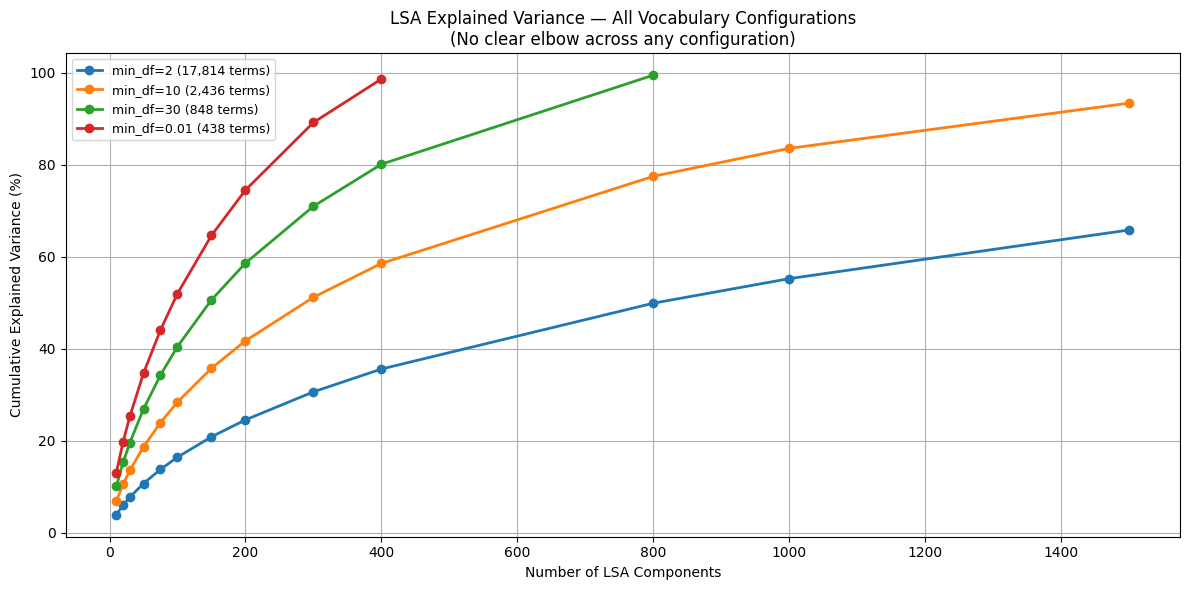

In [2]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

configs = {
    'min_df=2 (17,814 terms)':   {'min_df': 2,    'max_df': 0.95},
    'min_df=10 (2,436 terms)':   {'min_df': 10,   'max_df': 0.95},
    'min_df=30 (848 terms)':     {'min_df': 30,   'max_df': 0.95},
    'min_df=0.01 (438 terms)':   {'min_df': 0.01, 'max_df': 0.95},
}

dims = [10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 800, 1000, 1500]

plt.figure(figsize=(12, 6))
for label, cfg in configs.items():
    vec = TfidfVectorizer(ngram_range=(1,2), min_df=cfg['min_df'], max_df=cfg['max_df'])
    matrix = vec.fit_transform(df_tfidf['text_tfidf'])
    vocab_size = matrix.shape[1]
    variances = []
    valid_dims = []
    for d in dims:
        if d >= vocab_size:
            break
        svd = TruncatedSVD(n_components=d, random_state=42)
        svd.fit_transform(matrix)
        variances.append(svd.explained_variance_ratio_.sum() * 100)
        valid_dims.append(d)
    plt.plot(valid_dims, variances, marker='o', linewidth=2, label=label)

plt.title('LSA Explained Variance — All Vocabulary Configurations\n(No clear elbow across any configuration)')
plt.xlabel('Number of LSA Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.legend(fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

### LSA Vector Space Visualization

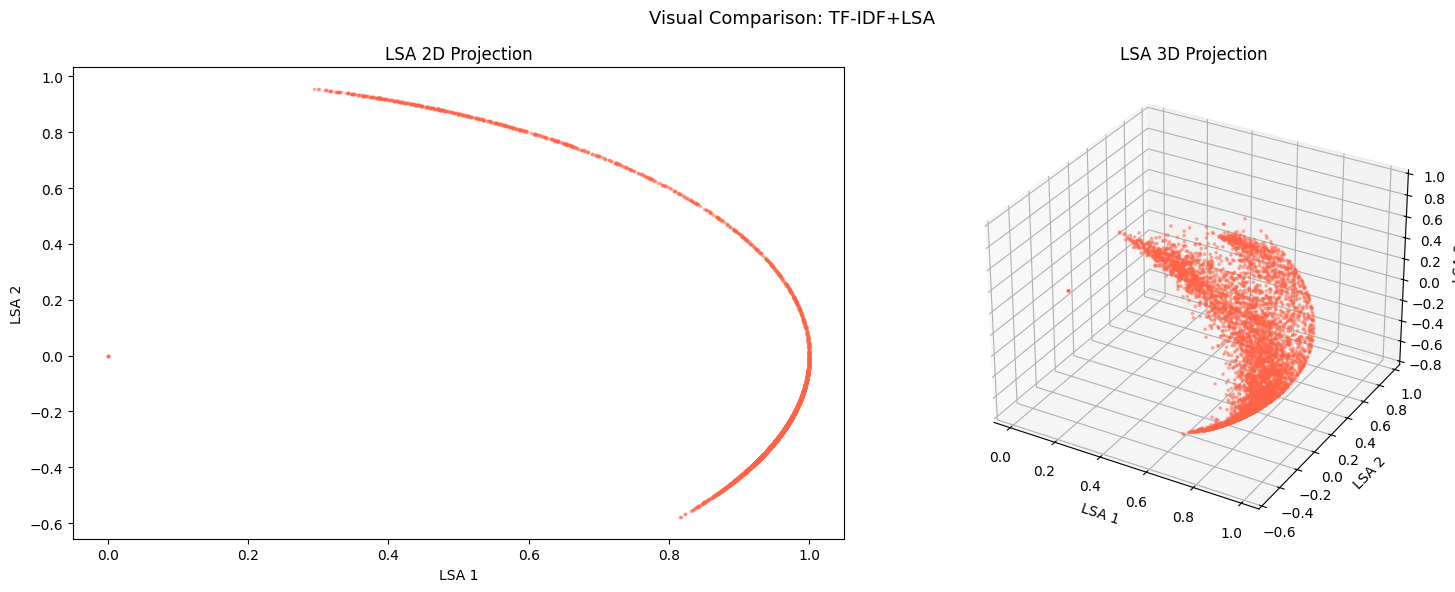

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# LSA configuration
vec = TfidfVectorizer(ngram_range=(1,2), min_df=10, max_df=0.95)
matrix = vec.fit_transform(df_tfidf['text_tfidf'])

# reduce to 2D directly to visualize
svd_2d = TruncatedSVD(n_components=2, random_state=42)
lsa_2d = svd_2d.fit_transform(matrix)
lsa_2d = Normalizer().fit_transform(lsa_2d)

# reduce LSA to 3D directly for visualization
svd_3d = TruncatedSVD(n_components=3, random_state=42)
lsa_3d = svd_3d.fit_transform(matrix)
lsa_3d = Normalizer().fit_transform(lsa_3d)

# Explicitly create ax2 with a 3D projection
fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# 2D Plot
ax1.scatter(lsa_2d[:, 0], lsa_2d[:, 1], s=3, alpha=0.4, color='tomato')
ax1.set_title('LSA 2D Projection')
ax1.set_xlabel('LSA 1')
ax1.set_ylabel('LSA 2')

# 3D Plot
ax2.scatter(lsa_3d[:, 0], lsa_3d[:, 1], lsa_3d[:, 2], s=3, alpha=0.4, color='tomato')
ax2.set_title('LSA 3D Projection')
ax2.set_xlabel('LSA 1')
ax2.set_ylabel('LSA 2')
ax2.set_zlabel('LSA 3')

plt.suptitle('Visual Comparison: TF-IDF+LSA ', fontsize=13)
plt.tight_layout()
plt.show()

## TF-IDF + LSA + K-Means

As shown in the plots above, there is not a clear cluster strucutre produced. Nevertheless, the pipeline is completed to empirically evaluate and 
document the performance of TF-IDF+LSA on this dataset.

The TF-IDF matrix was configured with `min_df=10` and `max_df=0.95`, producing a vocabulary 
of 2,436 terms — the most balanced configuration between vocabulary coverage and noise 
reduction. LSA was applied with 300 components, capturing 51.2% of the explained variance. 
K-Means was fitted with k=5 clusters.

In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# build TF-IDF with chosen configuration
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=10, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(df_tfidf['text_tfidf'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# build LSA matrix with 300 components
svd = TruncatedSVD(n_components=300, random_state=42)
lsa_matrix = svd.fit_transform(tfidf_matrix)
lsa_matrix = Normalizer().fit_transform(lsa_matrix)
print(f"LSA matrix shape: {lsa_matrix.shape}")
print(f"Explained variance: {svd.explained_variance_ratio_.sum()*100:.1f}%")

TF-IDF matrix shape: (5928, 2436)
LSA matrix shape: (5928, 300)
Explained variance: 51.2%


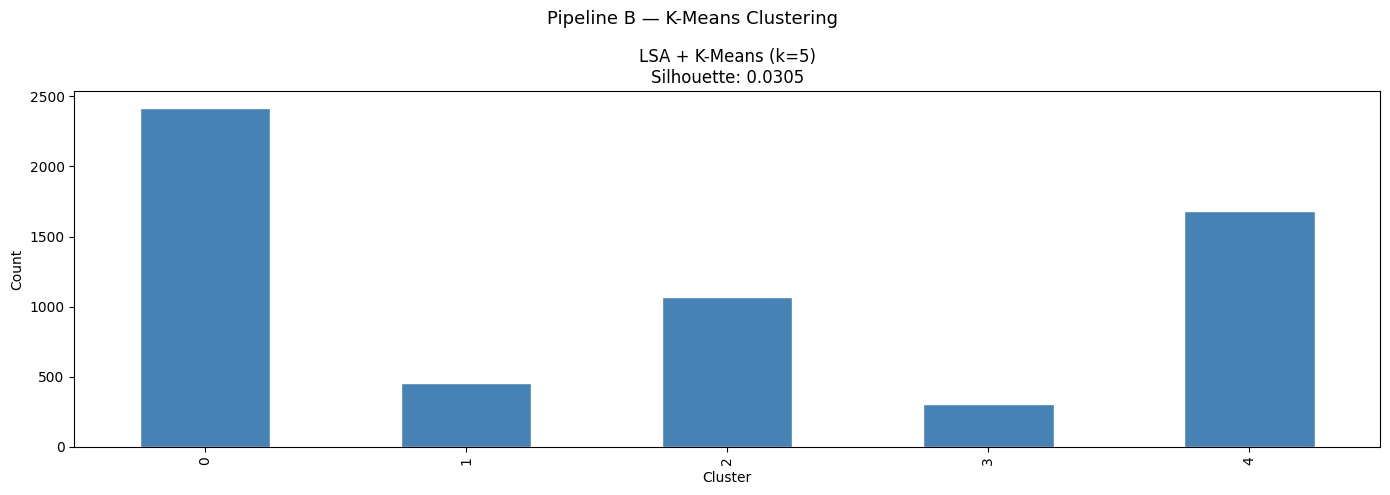

In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── K-Means on LSA (cosine via normalization) ──────────────────────────────────
km_lsa = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_lsa = km_lsa.fit_predict(lsa_matrix)
score_lsa = silhouette_score(lsa_matrix, labels_lsa)
df_tfidf['cluster'] = labels_lsa
# ── plot cluster sizes side by side ───────────────────────────────────────────
fig, (ax1) = plt.subplots(figsize=(14, 5))

# LSA clusters
import pandas as pd
pd.Series(labels_lsa).value_counts().sort_index().plot(
    kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title(f'LSA + K-Means (k=5)\nSilhouette: {score_lsa:.4f}')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Count')

plt.suptitle('Pipeline B — K-Means Clustering ', fontsize=13)
plt.tight_layout()
plt.show()

## Topic Extraction with C-TF-IDF

Although C-TF-IDF produced interpretable topic labels, the silhouette score of 0.039 
indicates poor geometric cluster separation in the LSA vector space. To verify that 
the topic extraction results were not a coincidence of a particular random initialization, 
K-Means was re-run across five different random seeds (0, 1, 22, 99, 123) to evaluate 
the reproducibility of the discovered clusters.

In [6]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# combine all texts per cluster into one document per cluster
cluster_docs = {}
for cluster_id in sorted(df_tfidf['cluster'].unique()):
    texts = df_tfidf[df_tfidf['cluster'] == cluster_id]['text_tfidf'].tolist()
    cluster_docs[cluster_id] = " ".join(texts)

# fit TF-IDF treating each cluster as one document
ctfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    ngram_range=(1, 2)
)
ctfidf_matrix = ctfidf_vectorizer.fit_transform(list(cluster_docs.values()))
feature_names = ctfidf_vectorizer.get_feature_names_out()

# extract top 5 terms per cluster
rows = []
ctfidf_results = {}
for idx, cluster_id in enumerate(sorted(cluster_docs.keys())):
    row = ctfidf_matrix[idx].toarray()[0]
    top_indices = row.argsort()[-5:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    ctfidf_results[cluster_id] = top_terms
    rows.append({
        'Cluster': cluster_id,
        'Size': (df_tfidf['cluster'] == cluster_id).sum(),
        'Top Terms (C-TF-IDF)': ', '.join(top_terms)
    })

df_ctfidf = pd.DataFrame(rows)
display(df_ctfidf.style.hide(axis='index'))

Cluster,Size,Top Terms (C-TF-IDF)
0,2416,"road, water, footpath, people, near"
1,452,"light, street light, street, light working, working"
2,1071,"garbage, road, people, day, collection"
3,306,"dog, stray dog, stray, night, barking"
4,1683,"road, pothole, main, condition, main road"


### Testing Different Seeds

In [7]:
for seed in [0, 1, 22, 99, 123]:
    km = KMeans(n_clusters=5, random_state=seed, n_init=10)
    labels = km.fit_predict(lsa_matrix)
    df_tfidf['cluster'] = labels
    
    # quick C-TF-IDF top term per cluster
    cluster_docs_test = {}
    for cluster_id in sorted(df_tfidf['cluster'].unique()):
        texts = df_tfidf[df_tfidf['cluster'] == cluster_id]['text_tfidf'].tolist()
        cluster_docs_test[cluster_id] = " ".join(texts)
    
    vec_test = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1,2))
    mat = vec_test.fit_transform(list(cluster_docs_test.values()))
    feat = vec_test.get_feature_names_out()
    
    print(f"\nseed={seed}")
    for idx, cluster_id in enumerate(sorted(cluster_docs_test.keys())):
        row = mat[idx].toarray()[0]
        top = [feat[i] for i in row.argsort()[-3:][::-1]]
        size = (df_tfidf['cluster'] == cluster_id).sum()
        print(f"  cluster {cluster_id} ({size}): {top}")


seed=0
  cluster 0 (2395): ['road', 'water', 'footpath']
  cluster 1 (452): ['light', 'street light', 'street']
  cluster 2 (1084): ['garbage', 'road', 'people']
  cluster 3 (306): ['dog', 'stray dog', 'stray']
  cluster 4 (1691): ['road', 'pothole', 'main']

seed=1
  cluster 0 (2409): ['road', 'water', 'footpath']
  cluster 1 (306): ['dog', 'stray dog', 'stray']
  cluster 2 (451): ['light', 'street light', 'street']
  cluster 3 (1687): ['road', 'pothole', 'main']
  cluster 4 (1075): ['garbage', 'road', 'people']

seed=22
  cluster 0 (452): ['light', 'street light', 'street']
  cluster 1 (1682): ['road', 'pothole', 'main']
  cluster 2 (1071): ['garbage', 'road', 'people']
  cluster 3 (306): ['dog', 'stray dog', 'stray']
  cluster 4 (2417): ['road', 'water', 'footpath']

seed=99
  cluster 0 (2420): ['road', 'water', 'footpath']
  cluster 1 (450): ['light', 'street light', 'street']
  cluster 2 (1680): ['road', 'pothole', 'main']
  cluster 3 (1072): ['garbage', 'road', 'people']
  clust

## Pipeline B — Results & Discussion

The seed  analysis confirmed that K-Means consistently recovers the same 5 topic 
groups regardless of initialization(only cluster labels get mixed), but the topic content 
remains identical across all seeds.Despite the geometric visual limitations of 
LSA representation, the topic extraction was executed with acceptable results. I attribute this behavior to the fact that K-means algorithm ran in a 300 dimenional space. I assume that in this high dimensional space, clusters are well separated, and the latter gets lost in 3D representations.

However, the results of Pipeline B are slightly less precise than those of Pipeline A. 
Topic labels produced in Pipeline B are interpretable but less semantically richer than those obtained in Pipeline A, where 
SBERT embeddings provided more meaningful semantic representations.

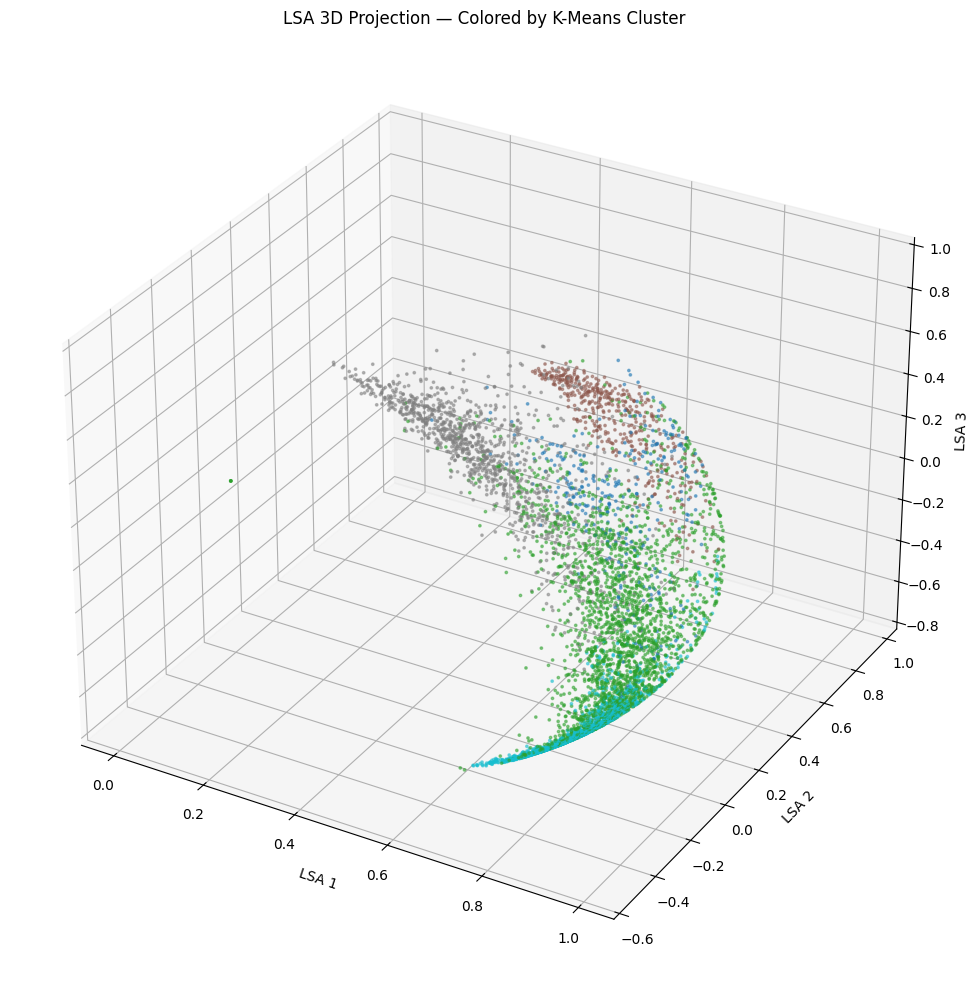

In [8]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
import numpy as np

# reduce LSA to 3D directly for visualization
svd_3d = TruncatedSVD(n_components=3, random_state=122)
lsa_3d = svd_3d.fit_transform(tfidf_matrix)
lsa_3d = Normalizer().fit_transform(lsa_3d)

# color by cluster
colors = plt.cm.tab10(np.linspace(0, 1, 5))
point_colors = [colors[l] for l in df_tfidf['cluster']]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    lsa_3d[:, 0],
    lsa_3d[:, 1],
    lsa_3d[:, 2],
    c=point_colors,
    s=3,
    alpha=0.5
)

ax.set_title('LSA 3D Projection — Colored by K-Means Cluster')
ax.set_xlabel('LSA 1')
ax.set_ylabel('LSA 2')
ax.set_zlabel('LSA 3')
plt.tight_layout()
plt.show()